# Fase 6 — Calibración sobre Test

**Métricas:** Expected Calibration Error (ECE, 10 bins), Integrated Calibration Index (ICI)  
**Gráficas:** Curvas de calibración (reliability diagrams) — 5 modelos × 3 targets

Un modelo bien calibrado satisface `P(outcome|score=p) ≈ p`, condición crítica en contextos clínicos donde las probabilidades predichas se usan directamente para tomar decisiones de triaje o activación de recursos. Probabilidades mal calibradas pueden llevar a decisiones erróneas incluso con AUROC elevado.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.calibration import calibration_curve

np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 150, 'font.size': 9})

ROOT    = Path("../..").resolve()
PREDS   = pd.read_parquet(ROOT / "data/processed/predictions_test.parquet")
TARGETS = ["L1", "L2", "L3"]
MODELS  = ["logreg", "catboost", "lstm", "tabtransformer", "nam"]
LABELS  = {"logreg": "LogReg+LASSO", "catboost": "CatBoost",
           "lstm": "LSTM", "tabtransformer": "TabTransformer", "nam": "NAM"}
COLORS  = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#AD1457"]
print(f"Test: {PREDS.shape[0]:,} pacientes")

Test: 59,641 pacientes


## 2. ECE e ICI

ECE (Expected Calibration Error) mide la discrepancia media entre probabilidad predicha y frecuencia observada en bins uniformes de anchura 0,1. ICI (Integrated Calibration Index) usa bins por cuantil de probabilidad, lo que lo hace más sensible a errores de calibración en la cola derecha de la distribución, especialmente relevante en clases muy desbalanceadas (L2, L3).

In [2]:
def ece(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (uniform bins)."""
    bins = np.linspace(0, 1, n_bins + 1)
    ece_val = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece_val += mask.sum() * abs(acc - conf)
    return ece_val / len(y_true)

def ici(y_true, y_prob, n_bins=20):
    """Integrated Calibration Index (mean absolute calibration error over quantile bins)."""
    quantiles = np.percentile(y_prob, np.linspace(0, 100, n_bins + 1))
    ici_val = 0.0
    count = 0
    for lo, hi in zip(quantiles[:-1], quantiles[1:]):
        mask = (y_prob >= lo) & (y_prob <= hi)
        if mask.sum() < 5:
            continue
        ici_val += abs(y_true[mask].mean() - y_prob[mask].mean())
        count += 1
    return ici_val / count if count > 0 else np.nan

rows = []
for t in TARGETS:
    y = PREDS[f"{t}_true"].values
    for m in MODELS:
        p = PREDS[f"{m}_{t}"].values
        rows.append({"Target": t, "Modelo": LABELS[m],
                     "ECE": ece(y, p), "ICI": ici(y, p)})

df_cal = pd.DataFrame(rows)
for t in TARGETS:
    print(f"\n=== {t} ===")
    print(df_cal[df_cal.Target == t].set_index("Modelo")[["ECE", "ICI"]].round(4).to_string())


=== L1 ===
                   ECE     ICI
Modelo                        
LogReg+LASSO    0.0868  0.0869
CatBoost        0.1117  0.1117
LSTM            0.1016  0.1016
TabTransformer  0.0354  0.0355
NAM             0.0984  0.0984

=== L2 ===
                   ECE     ICI
Modelo                        
LogReg+LASSO    0.2693  0.2693
CatBoost        0.1688  0.1688
LSTM            0.2613  0.2613
TabTransformer  0.3421  0.3421
NAM             0.3115  0.3115

=== L3 ===
                   ECE     ICI
Modelo                        
LogReg+LASSO    0.2428  0.2428
CatBoost        0.3389  0.3389
LSTM            0.2155  0.2155
TabTransformer  0.2468  0.2468
NAM             0.2705  0.2705


## 3. Curvas de calibración (reliability diagrams)

Se visualiza la calibración de cada modelo mediante reliability diagrams: la diagonal perfecta indica calibración ideal. La dispersión respecto a la diagonal y los valores ECE/ICI cuantifican la magnitud del error de calibración, especialmente pronunciado en L2 y L3 (clases muy desbalanceadas).

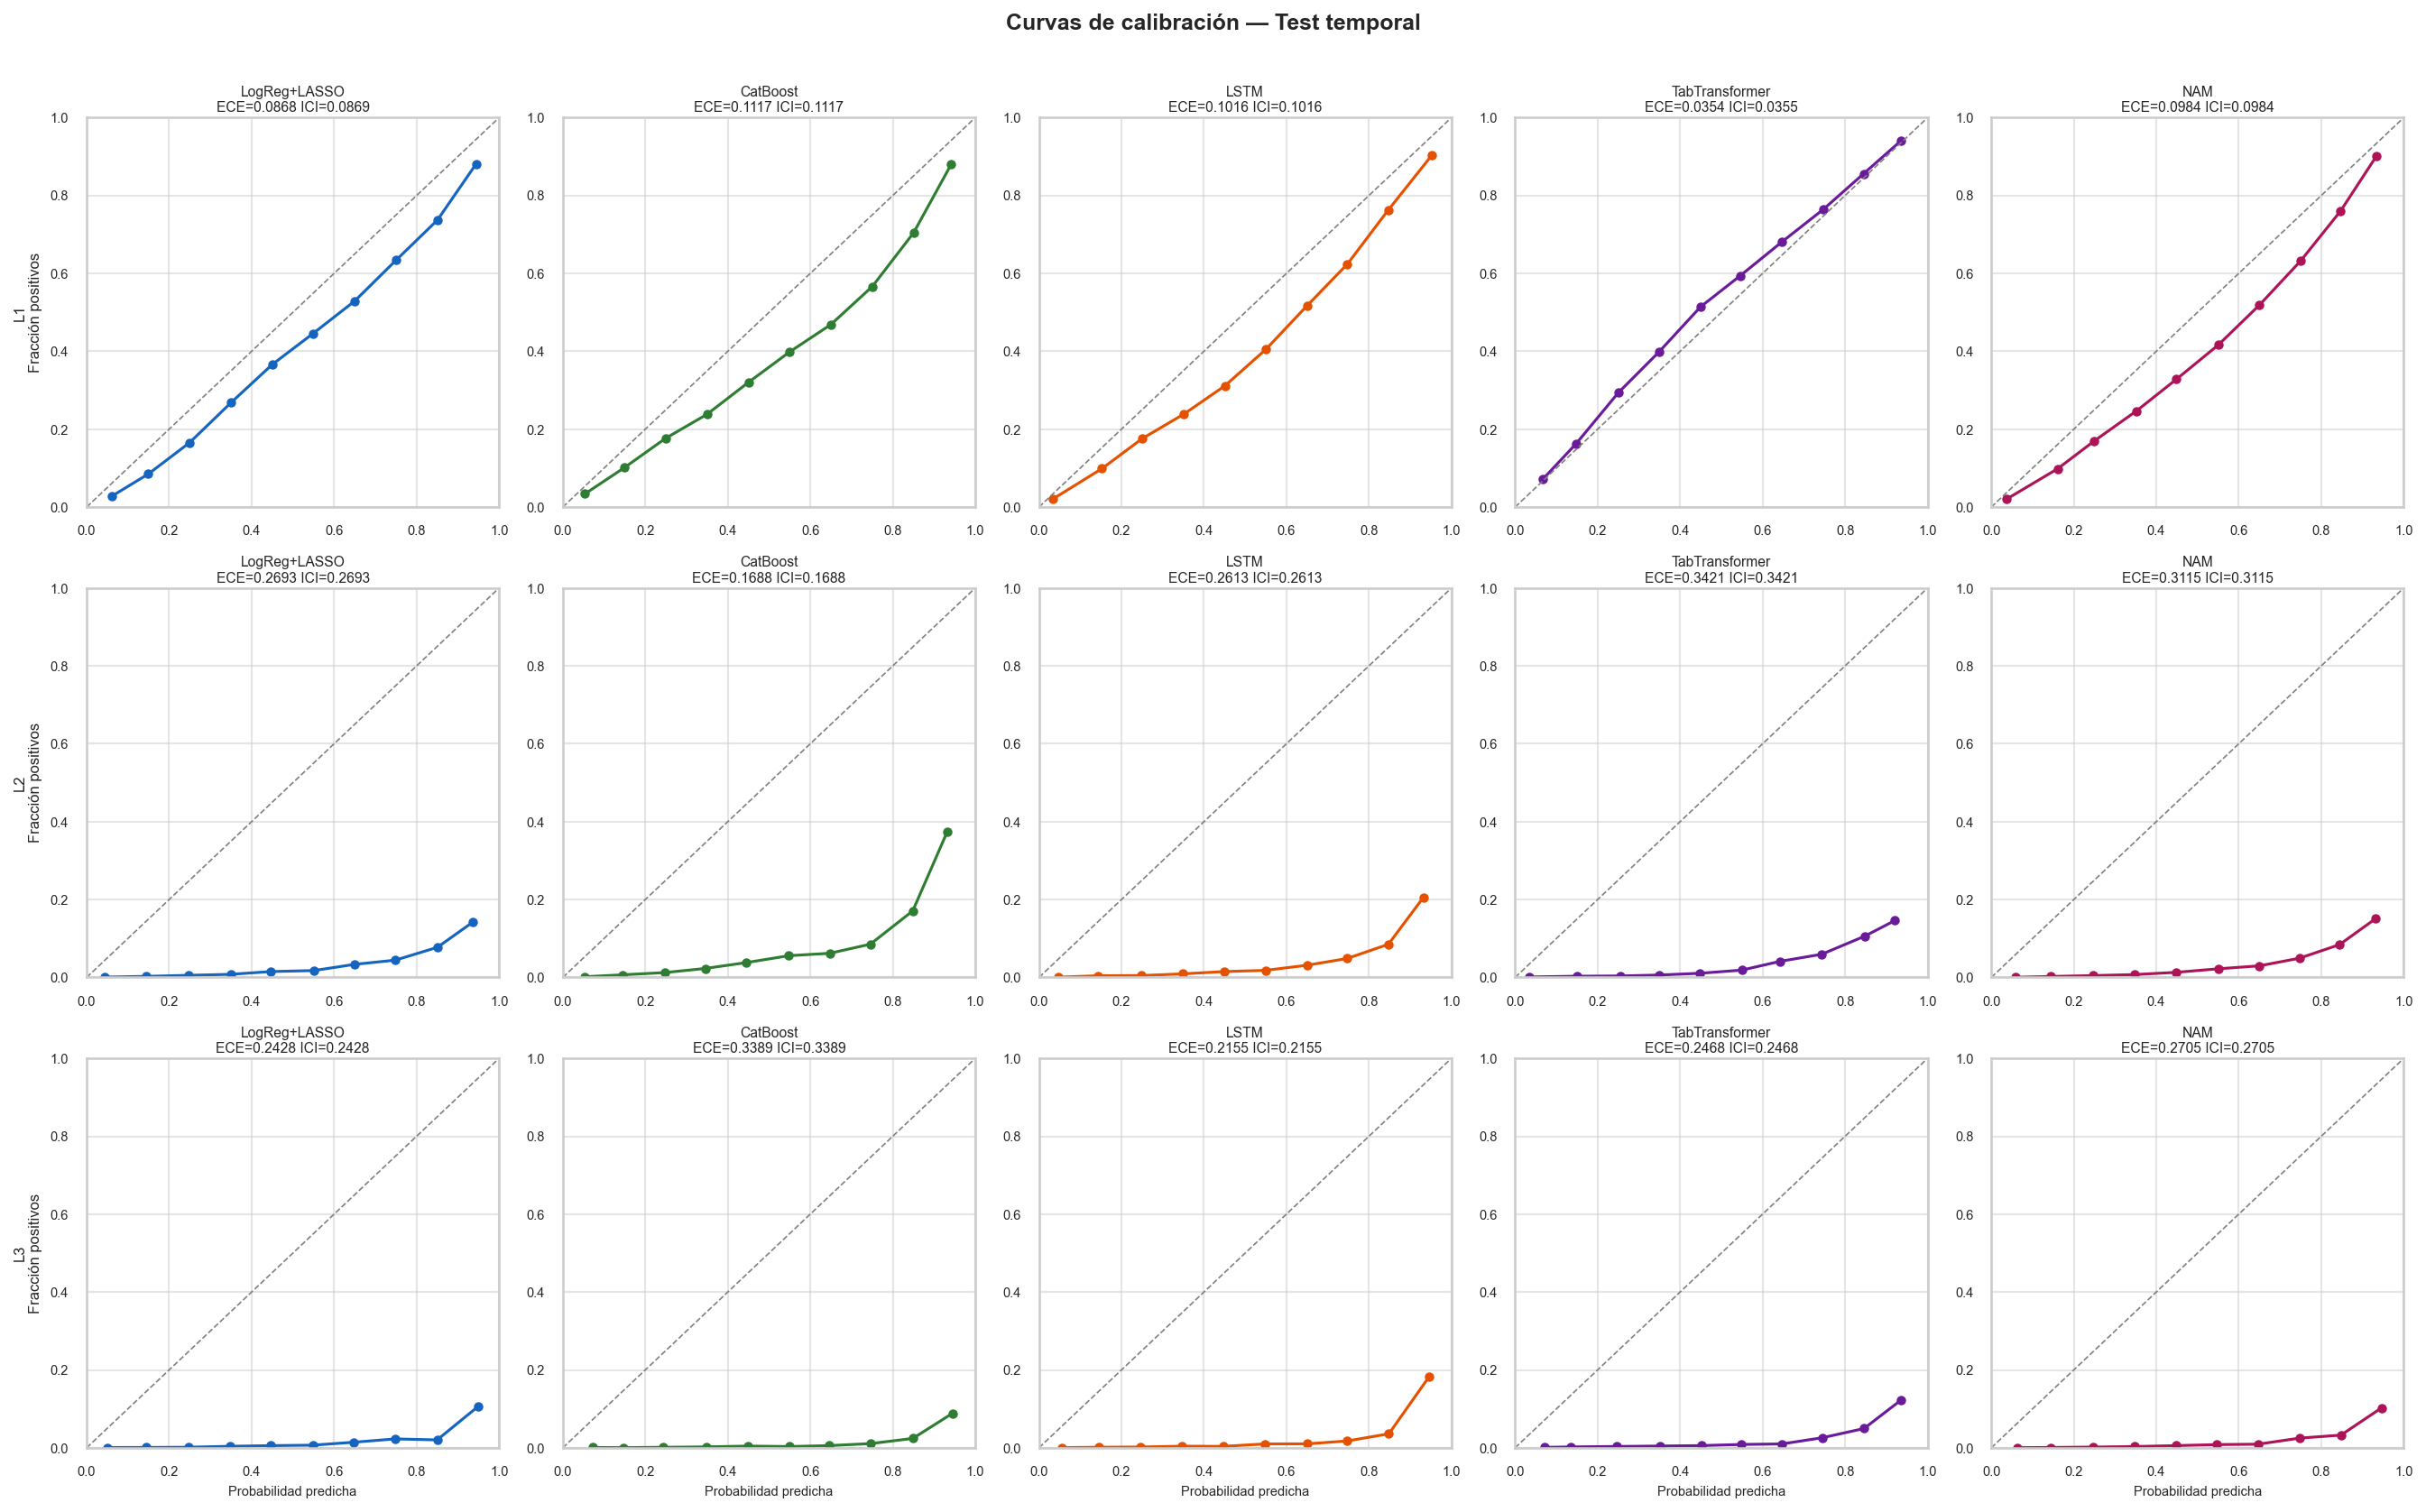

Guardado


In [3]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for row, t in enumerate(TARGETS):
    y = PREDS[f"{t}_true"].values
    for col, (m, color) in enumerate(zip(MODELS, COLORS)):
        ax = axes[row, col]
        p = PREDS[f"{m}_{t}"].values
        prob_true, prob_pred = calibration_curve(y, p, n_bins=10, strategy="uniform")
        ax.plot(prob_pred, prob_true, marker="o", ms=4, color=color, lw=1.5)
        ax.plot([0, 1], [0, 1], "--", color="gray", lw=0.8)
        sub = df_cal[(df_cal.Target == t) & (df_cal.Modelo == LABELS[m])]
        ece_v = sub.ECE.values[0]
        ici_v = sub.ICI.values[0]
        ax.set_title(f"{LABELS[m]}\nECE={ece_v:.4f} ICI={ici_v:.4f}",
                     fontsize=7.5, pad=3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(labelsize=7)
        if col == 0:
            ax.set_ylabel(f"{t}\nFracción positivos", fontsize=8)
        if row == 2:
            ax.set_xlabel("Probabilidad predicha", fontsize=7)

plt.suptitle("Curvas de calibración — Test temporal", fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
FIG = ROOT / "reports/figures"
plt.savefig(FIG / "test_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

df_cal.to_csv(ROOT / "reports/tables/test_calibration.csv", index=False)
print("Guardado")

Las curvas de calibración (reliability diagrams) muestran que los modelos presentan una calibración aceptable en L1 pero con desviaciones sistemáticas en L2 y L3. El patrón más frecuente es una curva en S: sobreconfianza en el rango de probabilidades bajas y subconfianza en el alto, lo que indica que el modelo comprime las predicciones hacia el centro. Este comportamiento es esperable en clasificadores entrenados con clases muy desbalanceadas sin calibración post-hoc. Los valores de ECE son consistentemente más altos en L2 y L3, donde la prevalencia baja (1,5% y 0,6%) agrava el desajuste. La calibración post-hoc (Platt scaling e isotónica) corrige estas desviaciones de forma drástica, como se analiza en el notebook 11.